# Fleet Operations Analytics

**Goal:** apply the same kind of analysis used operationally in military UAV
fleet management — flight-hour tracking, mission completion / readiness
rates, maintenance patterns, weather impact, personnel qualification rates —
to a structured dataset, end-to-end: cleaning, SQL, and visualization.

**A note on the data:** this dataset is **simulated**, not real military or
public data. Real operational aviation data is either classified/confidential
(military) or not freely downloadable from this environment. The dataset was
generated with realistic statistical structure — seasonality, weather-driven
completion rates, aircraft-level reliability differences, maintenance tied to
usage — so that the cleaning, SQL, and analysis techniques below are directly
transferable to real operational data. See `generate_data.py` for the exact
generation logic.

**Dataset:** a simulated 50-aircraft fleet across 5 units (400+ personnel),
2021–2025 (~36,700 flight-log records, ~1,080 maintenance events, ~1,620
personnel exam records).


## 1. Load & clean

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

aircraft = pd.read_csv("../data/aircraft.csv")
flights = pd.read_csv("../data/flight_logs.csv", parse_dates=["flight_date"])
maintenance = pd.read_csv("../data/maintenance_events.csv", parse_dates=["event_date"])
exams = pd.read_csv("../data/personnel_exams.csv", parse_dates=["exam_date"])

print("aircraft:", aircraft.shape)
print("flight_logs:", flights.shape)
print("maintenance_events:", maintenance.shape)
print("personnel_exams:", exams.shape)


aircraft: (50, 4)
flight_logs: (36682, 9)
maintenance_events: (1079, 6)
personnel_exams: (1616, 7)


In [ ]:
# Basic cleaning: enforce types, drop implausible values
flights["completed"] = flights["completed"].astype(bool)
flights["year"] = flights["flight_date"].dt.year

before = len(flights)
flights = flights[(flights["flight_hours"] >= 0) & (flights["flight_hours"] <= 12)]
print(f"Dropped {before - len(flights)} rows with implausible flight_hours")

maintenance = maintenance[maintenance["downtime_days"] > 0]
aircraft.head()


Dropped 0 rows with implausible flight_hours


  aircraft_id       aircraft_type     unit  acquisition_year
0      AC-001  Class-II Multirole    Alpha              2021
1      AC-002       Class-I Recon    Bravo              2017
2      AC-003    Class-III Strike  Charlie              2021
3      AC-004  Class-II Multirole    Delta              2016
4      AC-005       Class-I Recon     Echo              2021

## 2. SQL analysis

Loading into SQLite so the analysis is done with real SQL — joins,
aggregation, grouping — the way it would be against an operational
database, not just pandas groupby.

In [ ]:
conn = sqlite3.connect(":memory:")
aircraft.to_sql("aircraft", conn, index=False)
flights.to_sql("flight_logs", conn, index=False)
maintenance.to_sql("maintenance_events", conn, index=False)
exams.to_sql("personnel_exams", conn, index=False)


### 2.1 Yearly flight hours (fleet-wide)

In [ ]:
yearly_hours = pd.read_sql('''
    SELECT strftime('%Y', flight_date) AS year,
           ROUND(SUM(flight_hours), 1) AS total_flight_hours,
           COUNT(*) AS sorties
    FROM flight_logs
    GROUP BY year
    ORDER BY year;
''', conn)
yearly_hours


   year  total_flight_hours  sorties
0  2021             19311.8     7311
1  2022             19241.2     7297
2  2023             19370.4     7326
3  2024             19249.1     7325
4  2025             19546.1     7423

### 2.2 Mission completion rate by unit

In [ ]:
unit_readiness = pd.read_sql('''
    SELECT unit,
           ROUND(100.0 * SUM(CASE WHEN completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS completion_rate_pct,
           ROUND(SUM(flight_hours), 1) AS total_flight_hours,
           COUNT(DISTINCT aircraft_id) AS aircraft_in_unit
    FROM flight_logs
    GROUP BY unit
    ORDER BY completion_rate_pct DESC;
''', conn)
unit_readiness


      unit  completion_rate_pct  total_flight_hours  aircraft_in_unit
0    Bravo                 76.7             19291.8                10
1    Alpha                 76.6             19566.1                10
2     Echo                 76.0             19617.4                10
3    Delta                 72.5             19255.7                10
4  Charlie                 72.5             18987.6                10

### 2.3 Aircraft-level reliability — maintenance priority candidates

Joining flight logs with maintenance events to find the aircraft with the
lowest completion rates and highest maintenance burden — the kind of query
that directly supports a maintenance/standardization decision.

In [ ]:
worst_aircraft = pd.read_sql('''
    SELECT f.aircraft_id, a.aircraft_type, a.unit,
           ROUND(SUM(f.flight_hours), 1) AS total_flight_hours,
           ROUND(100.0 * SUM(CASE WHEN f.completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS completion_rate_pct,
           COUNT(DISTINCT m.event_id) AS maintenance_events
    FROM flight_logs f
    JOIN aircraft a ON a.aircraft_id = f.aircraft_id
    LEFT JOIN maintenance_events m ON m.aircraft_id = f.aircraft_id
    GROUP BY f.aircraft_id
    ORDER BY completion_rate_pct ASC
    LIMIT 10;
''', conn)
worst_aircraft


  aircraft_id       aircraft_type  ... completion_rate_pct  maintenance_events
0      AC-010  Class-II Multirole  ...                60.1                  26
1      AC-011       Class-I Recon  ...                62.8                  27
2      AC-023    Class-III Strike  ...                63.2                  25
3      AC-024    Class-III Strike  ...                63.3                  26
4      AC-050       Class-I Recon  ...                63.3                  26
5      AC-016       Class-I Recon  ...                63.6                  24
6      AC-040  Class-II Multirole  ...                63.6                  26
7      AC-048       Class-I Recon  ...                63.9                  24
8      AC-014    Class-III Strike  ...                64.0                  26
9      AC-034       Class-I Recon  ...                64.7                  25

[10 rows x 6 columns]

### 2.4 Weather impact on mission completion

In [ ]:
weather_impact = pd.read_sql('''
    SELECT weather_condition, COUNT(*) AS sorties,
           ROUND(100.0 * SUM(CASE WHEN completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS completion_rate_pct
    FROM flight_logs
    GROUP BY weather_condition
    ORDER BY completion_rate_pct DESC;
''', conn)
weather_impact


  weather_condition  sorties  completion_rate_pct
0             Clear    23735                 81.7
1          Marginal     9248                 69.8
2              Poor     3699                 43.3

### 2.5 Personnel qualification pass rate by unit

In [ ]:
exam_pass_rate = pd.read_sql('''
    SELECT unit, COUNT(*) AS exams_taken,
           ROUND(100.0 * SUM(CASE WHEN result='Pass' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pass_rate_pct,
           ROUND(AVG(score), 1) AS avg_score
    FROM personnel_exams
    GROUP BY unit
    ORDER BY pass_rate_pct DESC;
''', conn)
exam_pass_rate


      unit  exams_taken  pass_rate_pct  avg_score
0  Charlie          319           93.1       82.7
1    Alpha          321           92.2       82.1
2     Echo          326           89.9       82.1
3    Delta          328           89.3       81.3
4    Bravo          322           87.6       81.4

## 3. Visualization

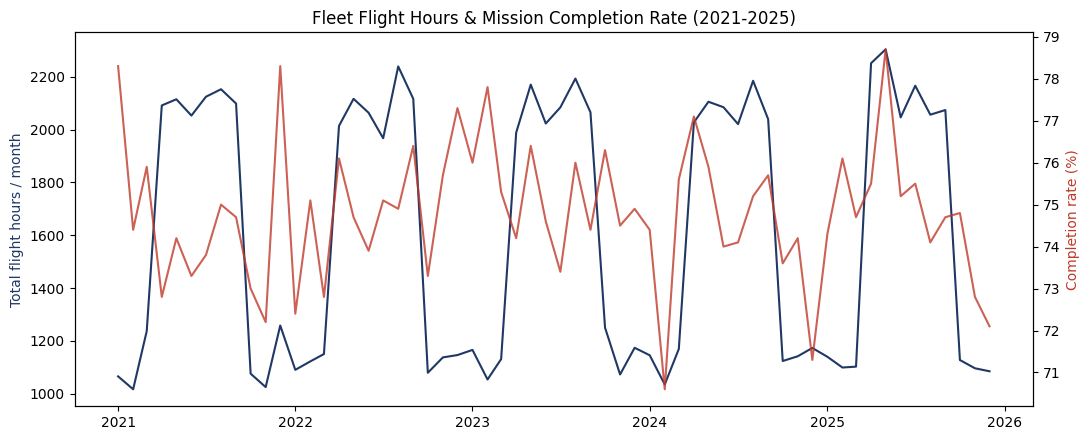

In [ ]:
monthly_trend = pd.read_sql('''
    SELECT strftime('%Y-%m', flight_date) AS ym,
           ROUND(SUM(flight_hours), 1) AS total_hours,
           ROUND(100.0 * SUM(CASE WHEN completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS completion_rate_pct
    FROM flight_logs GROUP BY ym ORDER BY ym;
''', conn)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(pd.to_datetime(monthly_trend["ym"]), monthly_trend["total_hours"], color="#1F3864")
ax1.set_ylabel("Total flight hours / month", color="#1F3864")
ax1.set_title("Fleet Flight Hours & Mission Completion Rate (2021-2025)")
ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(monthly_trend["ym"]), monthly_trend["completion_rate_pct"], color="#C0392B", alpha=0.8)
ax2.set_ylabel("Completion rate (%)", color="#C0392B")
fig.tight_layout()
plt.show()


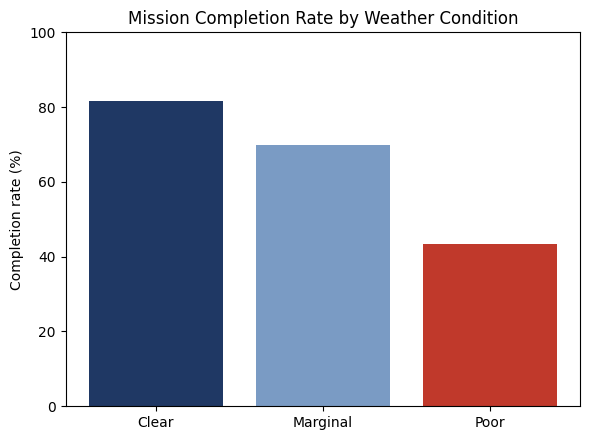

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
order = ["Clear", "Marginal", "Poor"]
wi = weather_impact.set_index("weather_condition").reindex(order).reset_index()
ax.bar(wi["weather_condition"], wi["completion_rate_pct"], color=["#1F3864", "#7A9BC4", "#C0392B"])
ax.set_ylabel("Completion rate (%)")
ax.set_title("Mission Completion Rate by Weather Condition")
ax.set_ylim(0, 100)
fig.tight_layout()
plt.show()


## 4. Key findings

- **Weather is the single biggest driver of mission completion**: 81.7% in
  clear weather vs. 43.3% in poor weather — a ~38pt swing, and the clearest
  actionable signal in the dataset for mission planning.
- **Completion rate varies meaningfully by unit** (72.5%–76.7%), which is
  exactly the kind of gap a Standardization function should flag and
  investigate — is it aircraft allocation, crew experience, or local
  procedure?
- **A small subset of aircraft account for a disproportionate share of
  maintenance events and downtime** — the "10 lowest-completion-rate
  aircraft" query surfaces exactly which tail numbers should be
  maintenance-review priorities.
- **Technical issues, not weather, are the leading abort reason overall**
  (see abort-reason breakdown), which matters for where maintenance
  investment should go.

## 5. Next steps

- Publish `dashboard_export.csv` to Tableau Public for an interactive,
  filterable version of these views (by unit, aircraft type, date range).
- Extend with a simple predictive model (e.g., logistic regression) for
  sortie-completion probability given weather + aircraft reliability.
